# Лабораторная работа 10 (часть 1)

## Цель
Построить **прогноз на 4 года** методом ARIMA

**Что такое ARIMA**

ARIMA — это аббревиатура: AR (авторегрессия) + I (интегрирование) + MA (скользящее среднее). Параметры записываются как ARIMA(p, d, q)

**AR(p)** — авторегрессия. Идея: текущее значение ряда зависит от его прошлых значений. Например, AR(2) означает, что сегодняшнее значение это взвешенная сумма двух предыдущих плюс случайный шум

**MA(q)** — скользящее среднее. Здесь текущее значение зависит не от прошлых значений ряда, а от прошлых ошибок прогноза. Т.е. как будто модель помнит насколько она ошиблась в прошлый раз и делает поправку

**I(d)** — интегрирование. Это просто количество раз, которое мы дифференцируем ряд, чтобы сделать его стационарным. d=1 означает, что мы работаем не с самим рядом, а с приростами

Для корректной работы ARIMA временной ряд должен быть стационарным.

Стационарный ряд обладает:
- постоянным средним,
- постоянной дисперсией,
- отсутствием выраженного тренда.

### Импорты

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

### Загрузка данных

   index   value
0      0  5717.0
1      1  6374.0
2      2  5837.5
3      3  7318.4
4      4  4613.0
Длина ряда: 38, среднее: 5991.6, std: 955.1


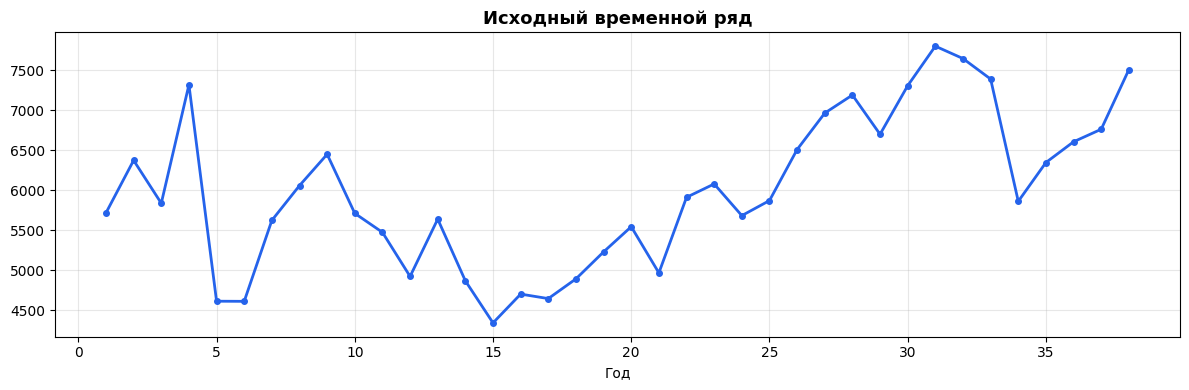

In [3]:
df = pd.read_csv('M3_152_0.csv', header=None, names=['index', 'value'])
series = df['value'].values
n = len(series)
print(df.head())
print(f"Длина ряда: {n}, среднее: {np.mean(series):.1f}, std: {np.std(series):.1f}")

plt.figure(figsize=(12, 4))
plt.plot(np.arange(1, n + 1), series, color='#2563eb', lw=2, marker='o', ms=4)
plt.title('Исходный временной ряд', fontsize=13, fontweight='bold')
plt.xlabel('Год')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Тест на стационарность

Для проверки стационарности используется тест Дики-Фуллера (ADF-test)

**H0:** ряд нестационарен (имеет единичный корень)

**H1:** ряд стационарен

----
если **p-value < 0.05** → отвергаем H0 → ряд считается стационарным  
если **p-value ≥ 0.05** → нет оснований отвергнуть H0 → ряд нестационарен 

In [4]:
adf_orig = adfuller(series)
print(f"ADF исходный ряд:    stat={adf_orig[0]:.3f}, p={adf_orig[1]:.4f}")


adf_diff1 = adfuller(np.diff(series, 1))
print(f"ADF 1-я разность:    stat={adf_diff1[0]:.3f}, p={adf_diff1[1]:.10f}")


ADF исходный ряд:    stat=-2.238, p=0.1928
ADF 1-я разность:    stat=-7.727, p=0.0000000000


Видно, что после 1 дифференцирования ряд становится стационарным, таким образом останавливаемся на параметре d = 1

In [5]:
series_diff1 = np.diff(series, n=1)

### ACF/PACF дифференцированного ряда

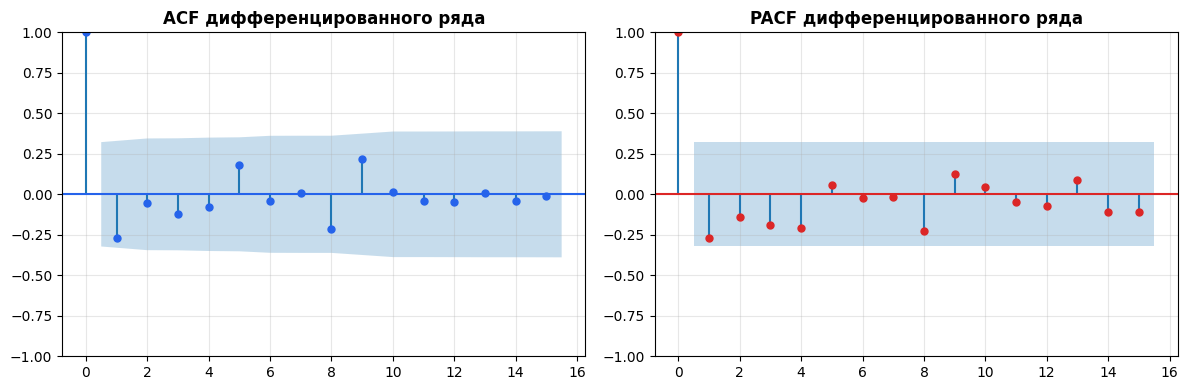

In [6]:
# ACF: если резко обрывается на лаге q → признак MA(q)
# PACF: если резко обрывается на лаге p → признак AR(p)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(series_diff1, lags=15, ax=axes[0], color='#2563eb', alpha=0.05)
axes[0].set_title('ACF дифференцированного ряда', fontweight='bold')
axes[0].grid(True, alpha=0.3)


plot_pacf(series_diff1, lags=15, ax=axes[1], color='#dc2626', alpha=0.05)
axes[1].set_title('PACF дифференцированного ряда', fontweight='bold')
axes[1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

### Перебор параметров

Исходя из теста на стационарность и графиков ACF и PACF можно предположить, что самая лучшая модель будет ARIMA (0,1,0). Однако, учитывая для повышения точности, проверим все близкие модели и выберем лучшую из них по метрике AIC:

- параметр интегрирования d = 1 
- параметр авторегрессии p находится в диапазоне [0, 1]
- параметр скользящего среднего q находится в диапазоне [0, 1]

In [7]:
# AIC штрафует за сложность модели, BIC штрафует сильнее
results = []
for p in range(0, 2):
    for d in [1]:
        for q in range(0, 2):
            try:
                m = ARIMA(series, order=(p, d, q)).fit()
                results.append({'order': (p, d, q), 'aic': round(m.aic, 2),
                                 'bic': round(m.bic, 2)})
            except Exception:
                pass

results_df = pd.DataFrame(results).sort_values('aic')
print("Топ-5 моделей")
print(results_df.head(5).to_string(index=False))

Топ-5 моделей
    order    aic    bic
(0, 1, 0) 596.45 598.07
(0, 1, 1) 596.52 599.75
(1, 1, 1) 596.66 601.49
(1, 1, 0) 597.11 600.33


### Проверка остатков (тест Льюнга-Бокса)

Если p > 0.05 — остатки не автокоррелированы → модель адекватна

p для ARIMA(0, 1, 0): 0.0072


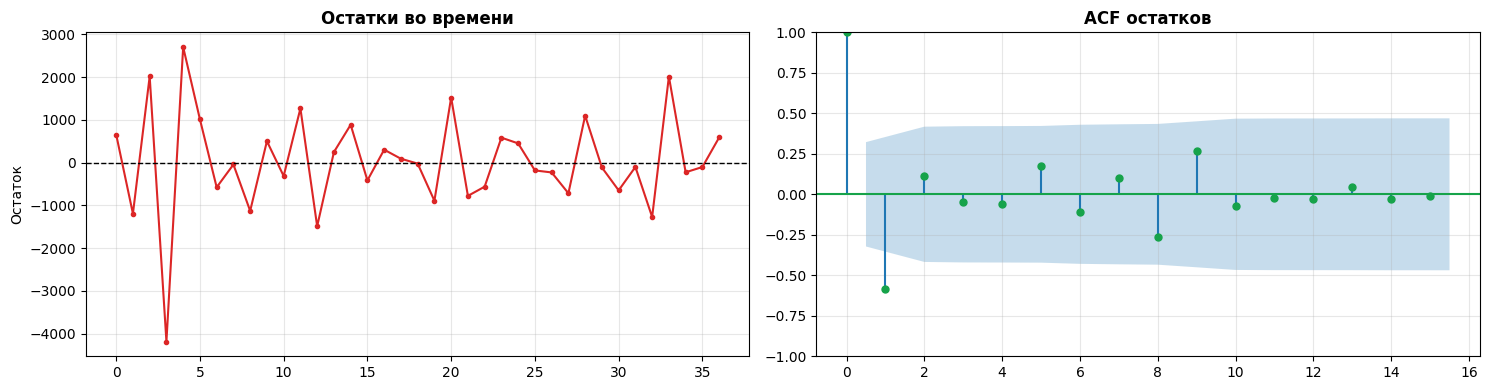

In [8]:
best_order = (0, 1, 0)

model_check = ARIMA(series_diff1, order=best_order).fit()
lb_test = acorr_ljungbox(model_check.resid, lags=[10], return_df=True)
print(f"p для ARIMA{best_order}: {lb_test['lb_pvalue'].values[0]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Остатки во времени
axes[0].plot(model_check.resid, color='#dc2626', lw=1.5, marker='o', ms=3)
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].set_title('Остатки во времени', fontweight='bold')
axes[0].set_ylabel('Остаток')
axes[0].grid(True, alpha=0.3)

# ACF остатков
plot_acf(model_check.resid, lags=15, ax=axes[1], color='#16a34a', alpha=0.05)
axes[1].set_title('ACF остатков', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

У модели ARIMA (0,1,0) - остатки автокоррелированы, что означает - информация в ряде еще осталась

Выберем модель с набибольшим значением p

p для ARIMA(1, 1, 1): 0.6798


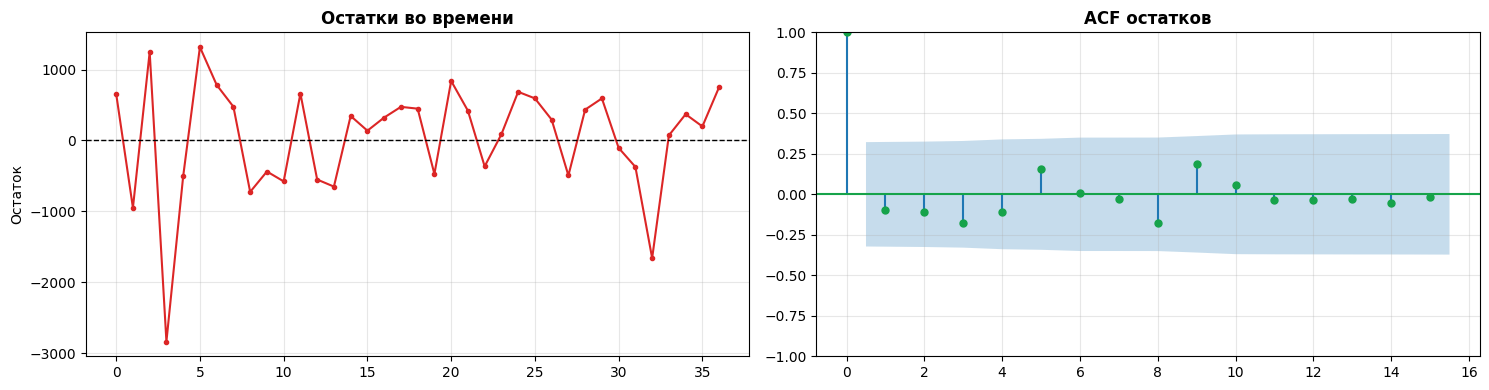

In [43]:
best_order = (1, 1, 1)

model_check = ARIMA(series_diff1, order=best_order).fit()
lb_test = acorr_ljungbox(model_check.resid, lags=[10], return_df=True)
print(f"p для ARIMA{best_order}: {lb_test['lb_pvalue'].values[0]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Остатки во времени
axes[0].plot(model_check.resid, color='#dc2626', lw=1.5, marker='o', ms=3)
axes[0].axhline(0, color='black', lw=1, ls='--')
axes[0].set_title('Остатки во времени', fontweight='bold')
axes[0].set_ylabel('Остаток')
axes[0].grid(True, alpha=0.3)

# ACF остатков
plot_acf(model_check.resid, lags=15, ax=axes[1], color='#16a34a', alpha=0.05)
axes[1].set_title('ACF остатков', fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Тестирование прогноза

Откладываем последние 4 наблюдения как тест и смотрим на метрики

In [44]:
train, test = series[:-4], series[-4:]
model_train = ARIMA(train, order=best_order).fit()
fc_test = model_train.forecast(steps=4)

mape = np.mean(np.abs((test - fc_test) / test)) * 100
mae  = np.mean(np.abs(test - fc_test))
rmse = np.sqrt(mean_squared_error(test, fc_test))
print(f"  Тестирование (последние 4 года):")
print(f"  Факт:    {np.round(test, 1)}")
print(f"  Прогноз: {np.round(fc_test, 1)}")
print("\n")
print(f"  Метрики качества:")
print(f"  MAPE: {mape:.2f}%")
print(f"  MAE:  {mae:.2f}")
print(f"  RMSE: {rmse:.2f}")

  Тестирование (последние 4 года):
  Факт:    [6346.7 6606.1 6762.7 7507.4]
  Прогноз: [6074.8 6205.6 6285.8 6335. ]


  Метрики качества:
  MAPE: 8.25%
  MAE:  580.43
  RMSE: 677.57


### Финальный прогноз

In [45]:
model_full = ARIMA(series, order=best_order).fit()
print(f"\nИтоговая модель:\n{model_full.summary()}")

fc_obj    = model_full.get_forecast(steps=4)
fc_future = fc_obj.predicted_mean
fc_ci     = fc_obj.conf_int(alpha=0.05)

print("\nПрогноз на 4 года вперёд:")
for i in range(4):
    print(f"  Год +{i+1}: {fc_future[i]:.1f}  (95% ДИ: [{fc_ci[i,0]:.1f}, {fc_ci[i,1]:.1f}])")


Итоговая модель:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                   38
Model:                 ARIMA(1, 1, 1)   Log Likelihood                -295.328
Date:                Thu, 14 May 2026   AIC                            596.655
Time:                        11:12:45   BIC                            601.488
Sample:                             0   HQIC                           598.359
                                 - 38                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4928      0.316      1.558      0.119      -0.127       1.112
ma.L1         -0.7843      0.238     -3.302      0.001      -1.250      -0.319
sigma2      4.824e+05   1.19e+05  

### Визуализация

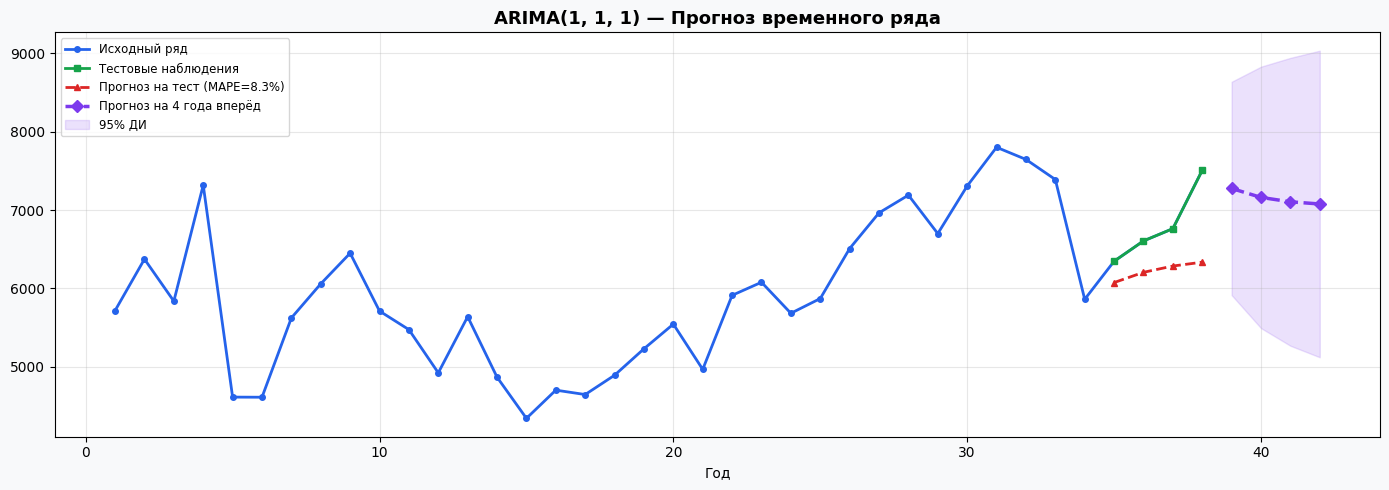

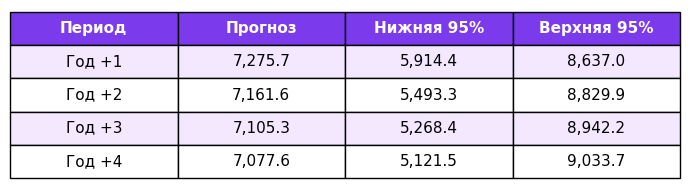

In [46]:
years_hist   = np.arange(1, n + 1)
years_test   = np.arange(n - 3, n + 1)
years_future = np.arange(n + 1, n + 5)

# Основной график
fig, ax1 = plt.subplots(figsize=(14, 5))
fig.patch.set_facecolor('#f8f9fa')
ax1.set_facecolor('white')
ax1.plot(years_hist, series, color='#2563eb', lw=2, marker='o', ms=4, label='Исходный ряд')
ax1.plot(years_test, test, color='#16a34a', lw=2, marker='s', ms=5, label='Тестовые наблюдения')
ax1.plot(years_test, fc_test, color='#dc2626', lw=2, ls='--', marker='^', ms=5,
         label=f'Прогноз на тест (MAPE={mape:.1f}%)')
ax1.plot(years_future, fc_future, color='#7c3aed', lw=2.5, ls='--', marker='D', ms=6,
         label='Прогноз на 4 года вперёд')
ax1.fill_between(years_future, fc_ci[:, 0], fc_ci[:, 1], color='#7c3aed', alpha=0.15,
                 label='95% ДИ')
ax1.set_title(f'ARIMA{best_order} — Прогноз временного ряда', fontsize=13, fontweight='bold')
ax1.set_xlabel('Год')
ax1.legend(fontsize=8.5, loc='upper left')
ax1.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Таблица
fig2, ax2 = plt.subplots(figsize=(7, 2))
ax2.axis('off')
table_data = [[f'Год +{i+1}', f'{fc_future[i]:,.1f}', f'{fc_ci[i,0]:,.1f}', f'{fc_ci[i,1]:,.1f}']
              for i in range(4)]
table = ax2.table(cellText=table_data,
                  colLabels=['Период', 'Прогноз', 'Нижняя 95%', 'Верхняя 95%'],
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 1.8)
for (r, c), cell in table.get_celld().items():
    if r == 0:
        cell.set_facecolor('#7c3aed')
        cell.set_text_props(color='white', fontweight='bold')
    else:
        cell.set_facecolor('#f3e8ff' if r % 2 else 'white')
plt.tight_layout()
plt.show()

### Вывод


В ходе выполнения лабораторной работы была рассмотрена модель прогнозирования временных рядов ARIMA. Основной задачей являлось построение модели, подбор её оптимальных параметров и прогнозирование значений на 4 года вперёд

На первом этапе был загружен и проанализирован временной ряд. Для оценки его свойств была выполнена проверка стационарности с использованием визуального анализа, автокорреляционных функций (ACF и PACF), а также теста Дики–Фуллера

Далее был проведён анализ ACF и PACF, который позволил получить предварительные оценки параметров модели ARIMA. На основе графической интерпретации было предположено, что простая модель ARIMA(0, d, 0) может быть базовым вариантом

Однако для более точного выбора параметров был выполнен перебор значений p и q с использованием информационного критерия AIC. В результате была выбрана оптимальная модель, обеспечивающая наилучшее качество описания данных

После обучения модели была проведена проверка на тестовой выборке. Метрики качества показали следующие результаты:
- MAE: 580.43  
- RMSE: 677.57 
- MAPE: 8.25%

Полученные значения свидетельствуют о достаточно хорошем качестве прогноза, так как средняя относительная ошибка составляет около 8%, что является приемлемым для задач анализа временных рядов

На заключительном этапе модель была обучена на полном наборе данных и использована для прогнозирования на 4 года вперёд. Полученные значения прогноза:

- 7275.7  
- 7161.6
- 7105.3 
- 7077.6